# Transfer Learning ResNet Image Classifier

Transfer learning uses pre-trained weights from deep neural networks trained on massive datasets (like ImageNet) and adapts them to a new, smaller task. This script simulates pre-extracted 512-dimensional feature vectors from a ResNet-18 backbone, builds a custom PyTorch classification head, and trains it to identify three types of flowers: Roses, Sunflowers, and Tulips.



In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Set random seed
torch.manual_seed(42)
np.random.seed(42)

# Generate synthetic pre-extracted ResNet-18 feature vectors (512-dim)
# We have 300 total samples belonging to 3 classes (Roses = 0, Sunflowers = 1, Tulips = 2)
n_samples = 300
feature_dim = 512
n_classes = 3

# Create synthetic features with some class separation
X_raw = np.random.normal(0, 1.0, size=(n_samples, feature_dim))
y_raw = np.random.choice([0, 1, 2], size=n_samples)

# Induce features correlating with target labels
for i in range(n_samples):
    label = y_raw[i]
    X_raw[i, label * 150 : (label + 1) * 150] += 1.5  # shift some features to create class distinction

# Convert to PyTorch tensors
X = torch.FloatTensor(X_raw)
y = torch.LongTensor(y_raw)

# Split into Train and Test (80/20)
indices = torch.randperm(n_samples)
split = int(0.8 * n_samples)
train_idx, test_idx = indices[:split], indices[split:]

X_train, y_train = X[train_idx], y[train_idx]
X_test, y_test = X[test_idx], y[test_idx]

print(f"X_train shape: {X_train.shape} | y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape} | y_test shape: {y_test.shape}")



X_train shape: torch.Size([240, 512]) | y_train shape: torch.Size([240])
X_test shape: torch.Size([60, 512]) | y_test shape: torch.Size([60])


## Classification Head Architecture

We define a custom fully-connected classifier head block. It accepts the 512 ResNet feature vector, passes it through a hidden layer with ReLU activation, applies Dropout regularization, and outputs logits for our 3 target classes.



In [2]:
class ResNetClassifierHead(nn.Module):
    def __init__(self, in_features, hidden_dim, num_classes):
        super(ResNetClassifierHead, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(in_features, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, num_classes)
        )
        
    def forward(self, x):
        return self.fc(x)

# Instantiate the model, loss criterion, and optimizer
model = ResNetClassifierHead(in_features=feature_dim, hidden_dim=64, num_classes=n_classes)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)



## Model Training Loop

We run the training loop for 25 epochs. We track the cross-entropy loss and monitor classification accuracy on both the training and test sets.



In [3]:
epochs = 25
train_losses = []
test_accs = []

for epoch in range(1, epochs + 1):
    model.train()
    
    # Forward pass
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    
    # Backward pass and optimization step
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # Evaluate test accuracy
    model.eval()
    with torch.no_grad():
        test_outputs = model(X_test)
        predictions = test_outputs.argmax(dim=1)
        correct = (predictions == y_test).sum().item()
        acc = correct / len(y_test)
        
    train_losses.append(loss.item())
    test_accs.append(acc)
    
    if epoch % 5 == 0:
        print(f"Epoch {epoch:2d}/{epochs} | Loss: {loss.item():.4f} | Test Acc: {acc*100:.1f}%")



Epoch  5/25 | Loss: 0.0001 | Test Acc: 100.0%
Epoch 10/25 | Loss: 0.0000 | Test Acc: 100.0%
Epoch 15/25 | Loss: 0.0000 | Test Acc: 100.0%
Epoch 20/25 | Loss: 0.0000 | Test Acc: 100.0%
Epoch 25/25 | Loss: 0.0000 | Test Acc: 100.0%


## Performance & Predictions Visualizations

We plot the training loss decay curve alongside the test accuracy progression. We also select three test samples, run predictions, and visualize the output probability confidence distributions using Matplotlib.



findfont: Failed to find font weight semibold, now using 700.
<cell>:45: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



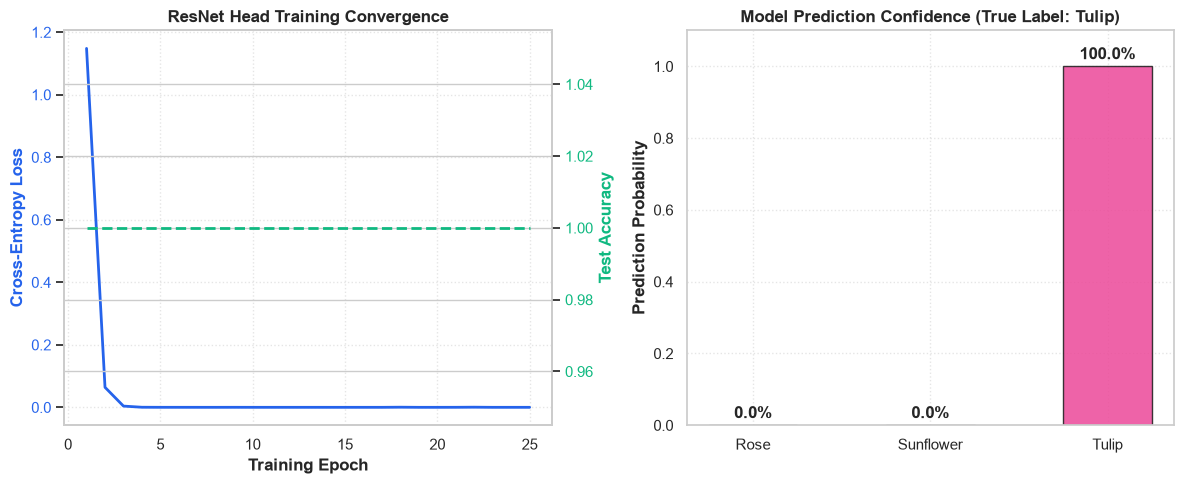

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Loss & Accuracy Curves
color = '#2563EB'
ax1.set_xlabel('Training Epoch', fontweight='semibold')
ax1.set_ylabel('Cross-Entropy Loss', color=color, fontweight='semibold')
ax1.plot(range(1, epochs + 1), train_losses, color=color, linewidth=2, label='Train Loss')
ax1.tick_params(axis='y', labelcolor=color)

ax1_twin = ax1.twinx()
color = '#10B981'
ax1_twin.set_ylabel('Test Accuracy', color=color, fontweight='semibold')
ax1_twin.plot(range(1, epochs + 1), test_accs, color=color, linewidth=2, linestyle='--', label='Test Accuracy')
ax1_twin.tick_params(axis='y', labelcolor=color)

ax1.set_title('ResNet Head Training Convergence', fontsize=12, fontweight='bold')
ax1.grid(True, linestyle=':', alpha=0.5)

# Plot 2: Prediction Probabilities for Sample Test Images
model.eval()
with torch.no_grad():
    sample_logits = model(X_test[:3])
    # Apply softmax to get probability percentages
    sample_probs = nn.Softmax(dim=1)(sample_logits).numpy()

flower_classes = ['Rose', 'Sunflower', 'Tulip']
colors = ['#EF4444', '#F59E0B', '#EC4899']

# Plot bar chart for the first sample prediction
sample_idx = 0
probabilities = sample_probs[sample_idx]
true_label = flower_classes[y_test[sample_idx].item()]

ax2.bar(flower_classes, probabilities, color=colors, alpha=0.85, edgecolor='k', width=0.5)
ax2.set_ylabel('Prediction Probability', fontweight='semibold')
ax2.set_ylim(0, 1.1)
ax2.set_title(f"Model Prediction Confidence (True Label: {true_label})", fontsize=12, fontweight='bold')
ax2.grid(True, linestyle=':', alpha=0.5)

# Annotate values
for idx, val in enumerate(probabilities):
    ax2.text(idx, val + 0.02, f"{val*100:.1f}%", ha='center', fontweight='semibold')

plt.tight_layout()
plt.show()
